# Introduction

This notebook walks throught the production of Fig. 07. This figure plots the difference in the spectra of the Stokes drift or significant wave height between the WW3-LVWD&CUR simulation and the WW3-NOXYZ simulations, where XYZ stands for the acronym relating to a mechanism being disabled.

## Imports

In [10]:
import sys
sys.path.append("../src")

In [53]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from spec_plot import (
    plot_variance_lost,
    add_spectral_slope,
)

from spectral_analysis import (
    variance_lost,
    isotropize,
)

plt.rcdefaults()
plt.style.use("../src/paper.mplstyle")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data

We compare the "full" run with all CEW mechanisms enabled (WW3-LVWD&CUR) to the models with one mechanism disabled (WW3-NOREF, NOCRT, NOREL, NOARV).

In [13]:
INPUT_DIR = Path('../data/spectra/')

In [14]:
ww3_lvwd_cur = xr.open_zarr(INPUT_DIR / 'lvwd_cur.zarr', consolidated=False)

ww3_noref = xr.open_zarr(INPUT_DIR / 'noref.zarr', consolidated=False)
ww3_nocrt = xr.open_zarr(INPUT_DIR / 'nocrt.zarr', consolidated=False)
ww3_norel = xr.open_zarr(INPUT_DIR / 'norel.zarr', consolidated=False)
ww3_noadv = xr.open_zarr(INPUT_DIR / 'noadv.zarr', consolidated=False)

# Mean 1D Spectra

In [18]:
us_lvwd_cur_vecspec = (ww3_lvwd_cur.uuss_PSD + ww3_lvwd_cur.vuss_PSD)

us_noref_vecspec = (ww3_noref.uuss_PSD + ww3_noref.vuss_PSD)
us_nocrt_vecspec = (ww3_nocrt.uuss_PSD + ww3_nocrt.vuss_PSD)
us_norel_vecspec = (ww3_norel.uuss_PSD + ww3_norel.vuss_PSD)
us_noadv_vecspec = (ww3_noadv.uuss_PSD + ww3_noadv.vuss_PSD)

In [26]:
hs_lvwd_cur_vecspec = ww3_lvwd_cur.hs_PSD

hs_noref_vecspec = ww3_noref.hs_PSD
hs_nocrt_vecspec = ww3_nocrt.hs_PSD
hs_norel_vecspec = ww3_norel.hs_PSD
hs_noadv_vecspec = ww3_noadv.hs_PSD

In [19]:
mean_us_lvwd_cur_vecspec = us_lvwd_cur_vecspec.mean(dim='time')

mean_us_noref_vecspec = us_noref_vecspec.mean(dim='time')
mean_us_nocrt_vecspec = us_nocrt_vecspec.mean(dim='time')
mean_us_norel_vecspec = us_norel_vecspec.mean(dim='time')
mean_us_noadv_vecspec = us_noadv_vecspec.mean(dim='time')

In [27]:
mean_hs_lvwd_cur_vecspec = hs_lvwd_cur_vecspec.mean(dim='time')

mean_hs_noref_vecspec = hs_noref_vecspec.mean(dim='time')
mean_hs_nocrt_vecspec = hs_nocrt_vecspec.mean(dim='time')
mean_hs_norel_vecspec = hs_norel_vecspec.mean(dim='time')
mean_hs_noadv_vecspec = hs_noadv_vecspec.mean(dim='time')

In [20]:
mean_iso_us_lvwd_cur_vecspec = isotropize(mean_us_lvwd_cur_vecspec)

mean_iso_us_noref_vecspec = isotropize(mean_us_noref_vecspec)
mean_iso_us_nocrt_vecspec = isotropize(mean_us_nocrt_vecspec)
mean_iso_us_norel_vecspec = isotropize(mean_us_norel_vecspec)
mean_iso_us_noadv_vecspec = isotropize(mean_us_noadv_vecspec)

In [28]:
mean_iso_hs_lvwd_cur_vecspec = isotropize(mean_hs_lvwd_cur_vecspec)

mean_iso_hs_noref_vecspec = isotropize(mean_hs_noref_vecspec)
mean_iso_hs_nocrt_vecspec = isotropize(mean_hs_nocrt_vecspec)
mean_iso_hs_norel_vecspec = isotropize(mean_hs_norel_vecspec)
mean_iso_hs_noadv_vecspec = isotropize(mean_hs_noadv_vecspec)

# Difference

We compute the percent of variance lost from the WW3-LVWD&CUR model to the WW3-NO___ model as
$$
\text{\% variance lost}(k) = 100 * \frac{P_\text{full}(k) - P_\text{nomech}(k)}{P_\text{full}(k)}
$$

In [29]:
us_full = mean_iso_us_lvwd_cur_vecspec

us_mechanisms = {
    "NOREF": mean_iso_us_noref_vecspec,
    "NOCRT": mean_iso_us_nocrt_vecspec,
    "NOREL": mean_iso_us_norel_vecspec,
    "NOADV": mean_iso_us_noadv_vecspec,
}

us_loss = variance_lost(us_full, us_mechanisms)

In [30]:
hs_full = mean_iso_hs_lvwd_cur_vecspec

hs_mechanisms = {
    "NOREF": mean_iso_hs_noref_vecspec,
    "NOCRT": mean_iso_hs_nocrt_vecspec,
    "NOREL": mean_iso_hs_norel_vecspec,
    "NOADV": mean_iso_hs_noadv_vecspec,
}

hs_loss = variance_lost(hs_full, hs_mechanisms)

In [51]:
fig07_styles = {
    "NOREF": {
        "color": "darkblue",
        "linestyle": "-.",
        "linewidth": 1.5,
    },
    "NOCRT": {
        "color": "royalblue",
        "linestyle": "-.",
        "linewidth": 1.5,
    },
    "NOADV": {
        "color": "blue",
        "linestyle": "-",
        "linewidth": 1.5,
    },
    "NOREL": {
        "color": "goldenrod",
        "linestyle": "-",
        "linewidth": 1.5,
    },
}

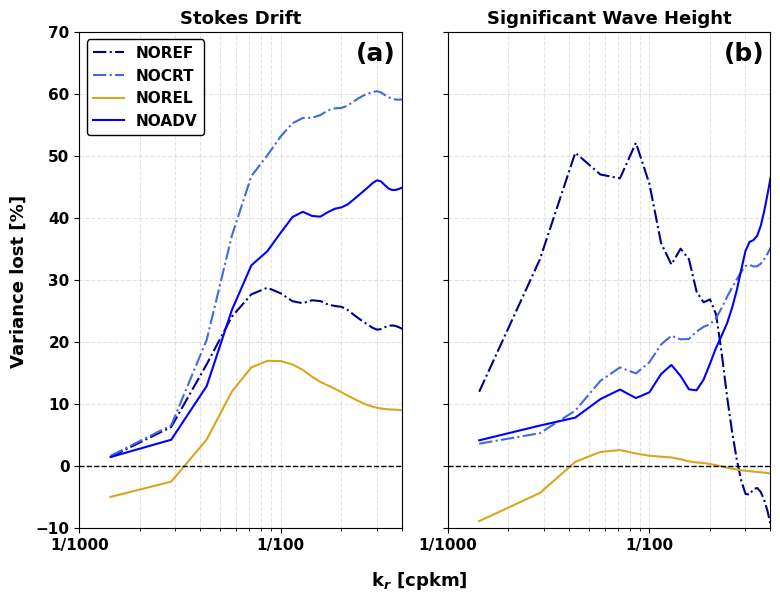

In [54]:
fig, axes = plot_variance_lost(
    datasets=[us_loss, hs_loss],
    titles=[
        "Stokes Drift",
        "Significant Wave Height",
    ],
    styles=fig07_styles,
)

plt.show()

In [55]:
fig.savefig(
    '../figures/fig07.png',
    dpi=500,
    bbox_inches='tight',
    pad_inches=0.1,
)